# Independent Single-band GP Baseline

In [1]:
%load_ext autoreload
%autoreload 2
from datasets import load_dataset
from data_processing import process_one_obj_one_band, split_train_heldout_observations, select_examples_and_global_flux_scale
from singleGP_model import (
    fit_basic_gp,
    evaluate_heldout_nlpd,
    evaluate_heldout_rmse,
    evaluate_heldout_metrics,
    summarize_object_metric_results,
    standardized_residual_statistics,
    largest_standardized_residual_cases,
    print_largest_standardized_residual_cases,
    cover_factor,
)
from visualization import plot_gp_fit, plot_largest_standardized_residual_cases

dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


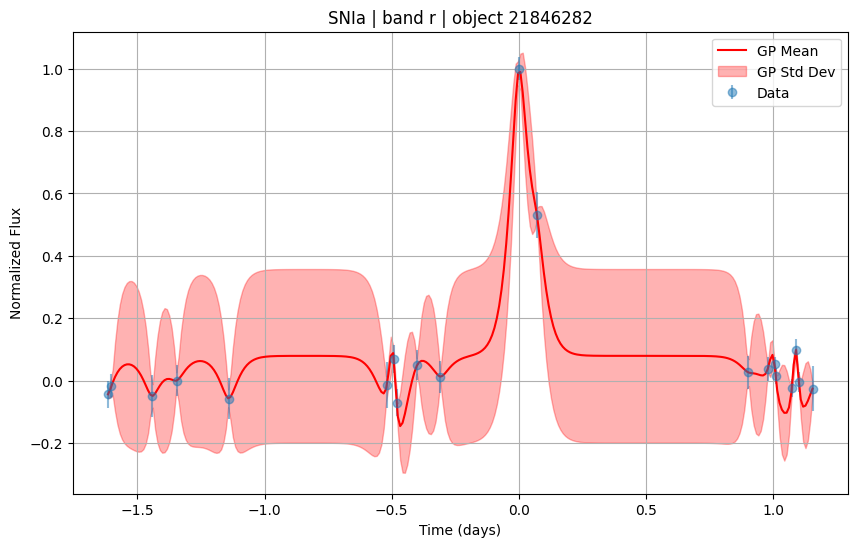

In [3]:
example = next(iter(dset_plasticc))

data = process_one_obj_one_band(example, target_band='r')
if data is not None:
    gp = fit_basic_gp(data, kernel_type="matern")
    plot_gp_fit(gp, data)

## Multi-objects on one band

Unconstrained Matern:kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=1.5)
And higher noise:0.3

In [8]:
import numpy as np

prepared_objects = []

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(500), dset_iterator):
    data = process_one_obj_one_band(
        example,
        target_band="r",
        align_peak=True,
        normalize_flux=True,
        min_points=8,
    )

    if data is not None:
        prepared_objects.append(data)
        print(np.min(data["yerr"]), np.median(data["yerr"]), np.max(data["yerr"]))

print("number of usable objects:", len(prepared_objects))

0.023923717 0.044506773 0.07394759
0.050455526 0.08186242 0.1243165
0.09897589 0.15759754 0.25484547
0.00036992045 0.0006143678 0.005009557
0.02172172 0.047246072 0.07114961
0.03311875 0.06707094 0.11008544
0.010196236 0.022302518 0.04054288
0.032263555 0.06865703 0.10954704
0.034623444 0.10556647 0.16789038
0.033959974 0.06508212 0.11091445
0.026309019 0.05469425 0.10455511
0.039679497 0.06941345 0.117931455
0.0036056964 0.00885603 0.015104389
0.0014955392 0.00448307 0.008963429
0.015701331 0.03085626 0.056639303
0.010919944 0.018603384 0.03727177
0.008556754 0.020484606 0.034463428
0.029406933 0.046728224 0.0890774
0.048371464 0.09180884 0.19809304
0.079814166 0.14818762 0.2264985
0.019528441 0.031279325 0.06783643
0.037351232 0.057684824 0.10662571
0.05415431 0.09277719 0.1547873
0.5313289 0.69672406 1.5314168
0.01587348 0.021993928 0.053439878
0.07077617 0.092653766 0.20290491
0.20072089 0.3292376 0.71703434
0.04184459 0.06628788 0.09637488
0.017610611 0.028007723 0.04016513
0.0322

In [17]:
from GP_model import extract_basic_gp_features

features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

0 21846282 SNIa 1.14**2 * Matern(length_scale=0.0423, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.301, nu=1.5)
2 30652072 SNII 0.946**2 * Matern(length_scale=0.0472, nu=1.5)
3 107732897 TDE 0.777**2 * Matern(length_scale=0.103, nu=1.5)
4 121186562 AGN 1.05**2 * Matern(length_scale=0.0393, nu=1.5)
5 10905347 SNII 1.07**2 * Matern(length_scale=0.0293, nu=1.5)
6 16775731 SNIa 0.801**2 * Matern(length_scale=0.046, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0746, nu=1.5)
8 50875482 SNIbc 1.09**2 * Matern(length_scale=0.0341, nu=1.5)
9 52437992 AGN 1.07**2 * Matern(length_scale=0.0823, nu=1.5)
10 100164081 SLSN-I 1.23**2 * Matern(length_scale=0.0389, nu=1.5)
11 6777396 AGN 0.948**2 * Matern(length_scale=0.0242, nu=1.5)
12 56002762 SNII 0.887**2 * Matern(length_scale=0.207, nu=1.5)
13 93866109 SNIbc 1.11**2 * Matern(length_scale=0.137, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.0427, nu=1.5)
15 41660164 SNIbc 1.19**2 * Matern(length_scale=0.0681, nu=1.5)

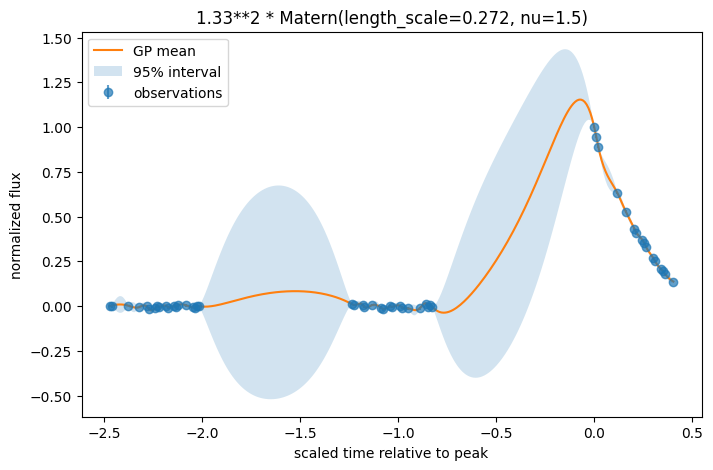

In [9]:
import matplotlib.pyplot as plt
def plot_gp_diagnostic(gp, data, n_grid=300):
    t = data["t"]
    y = data["y"]
    yerr = data["yerr"]

    t_grid = np.linspace(t.min(), t.max(), n_grid)
    X_grid = t_grid.reshape(-1, 1)

    mean, std = gp.predict(X_grid, return_std=True)

    plt.figure(figsize=(8, 5))
    plt.errorbar(t, y, yerr=yerr, fmt="o", alpha=0.7, label="observations")
    plt.plot(t_grid, mean, label="GP mean")
    plt.fill_between(t_grid, mean - 2*std, mean + 2*std, alpha=0.2, label="95% interval")
    plt.xlabel("scaled time relative to peak")
    plt.ylabel("normalized flux")
    plt.title(str(gp.kernel_))
    plt.legend()
    plt.show()
plot_gp_diagnostic(gp, data)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

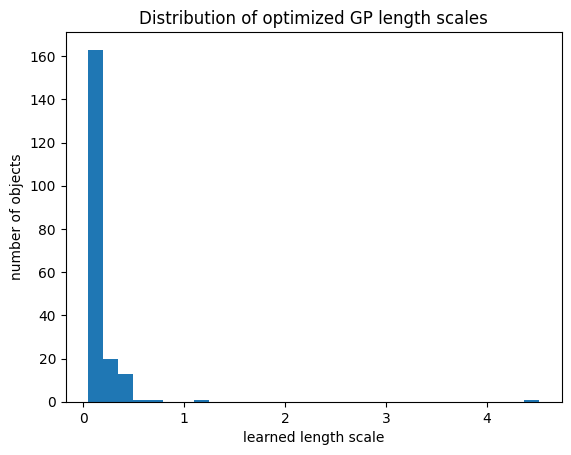

In [18]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

In [20]:
print("median ell:", np.median(ells))
print("min ell:", np.min(ells))
print("max ell:", np.max(ells))
print("fraction near lower bound:", np.mean(np.array(ells) <= 0.051))

median ell: 0.0638863908216447
min ell: 0.05000000000000001
max ell: 4.516997073610352
fraction near lower bound: 0.455


### Constrained Matern:

In [13]:
features = []
labels = []

for data in prepared_objects:   # Iterate over each prepared object
    gp = fit_basic_gp(data, kernel_type="matern")
    feat = extract_basic_gp_features(gp, data)
    features.append([feat['peak_flux'], feat['peak_time'], feat['decay_slope'], feat['mean_uncertainty']])
    labels.append(data['obj_type'])

X_features = np.array(features)
y_labels = np.array(labels)

print(X_features.shape)
print(y_labels.shape)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

(500, 4)
(500,)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
for idx, data in enumerate(prepared_objects[:20]):
    gp = fit_basic_gp(data)
    print(idx, data["obj_id"], data["obj_type"], gp.kernel_)

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0 21846282 SNIa 1.2**2 * Matern(length_scale=0.05, nu=1.5)
1 114421739 AGN 1.03**2 * Matern(length_scale=0.321, nu=1.5)
2 30652072 SNII 0.951**2 * Matern(length_scale=0.05, nu=1.5)
3 107732897 TDE 0.772**2 * Matern(length_scale=0.0999, nu=1.5)
4 121186562 AGN 1.14**2 * Matern(length_scale=0.05, nu=1.5)
5 10905347 SNII 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

6 16775731 SNIa 0.828**2 * Matern(length_scale=0.05, nu=1.5)
7 31971611 SNII 1.01**2 * Matern(length_scale=0.0751, nu=1.5)
8 50875482 SNIbc 1.23**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


9 52437992 AGN 1.08**2 * Matern(length_scale=0.0864, nu=1.5)
10 100164081 SLSN-I 1.34**2 * Matern(length_scale=0.05, nu=1.5)
11 6777396 AGN 1.13**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


12 56002762 SNII 0.888**2 * Matern(length_scale=0.209, nu=1.5)
13 93866109 SNIbc 1.08**2 * Matern(length_scale=0.136, nu=1.5)
14 31725628 SNII 1.11**2 * Matern(length_scale=0.288, nu=1.5)
15 41660164 SNIbc 1.2**2 * Matern(length_scale=0.0781, nu=1.5)
16 43441391 TDE 1.14**2 * Matern(length_scale=0.105, nu=1.5)
17 46741316 SNIa 1.39**2 * Matern(length_scale=0.05, nu=1.5)
18 56383332 SNIax 0.893**2 * Matern(length_scale=0.0727, nu=1.5)
19 26794348 SNII 1.39**2 * Matern(length_scale=0.05, nu=1.5)


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  w

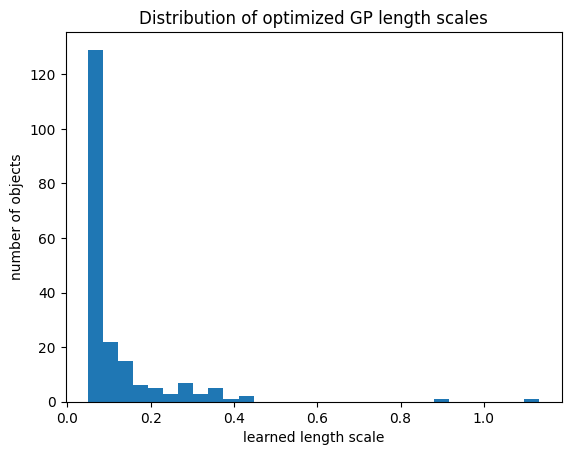

In [15]:
ells = []

for data in prepared_objects[:200]:
    gp = fit_basic_gp(data)

    params = gp.kernel_.get_params()

    if "k2__length_scale" in params:
        ell = params["k2__length_scale"]
        ells.append(ell)
    else:
        print("Could not find length scale for kernel:", gp.kernel_)

plt.hist(ells, bins=30)
plt.xlabel("learned length scale")
plt.ylabel("number of objects")
plt.title("Distribution of optimized GP length scales")
plt.show()

constrained Matérn optimization still tends to choose very short length scales as well

## Fixed length scale experiment

ell = 0.1
kernel after fit: 1**2 * Matern(length_scale=0.1, nu=1.5)


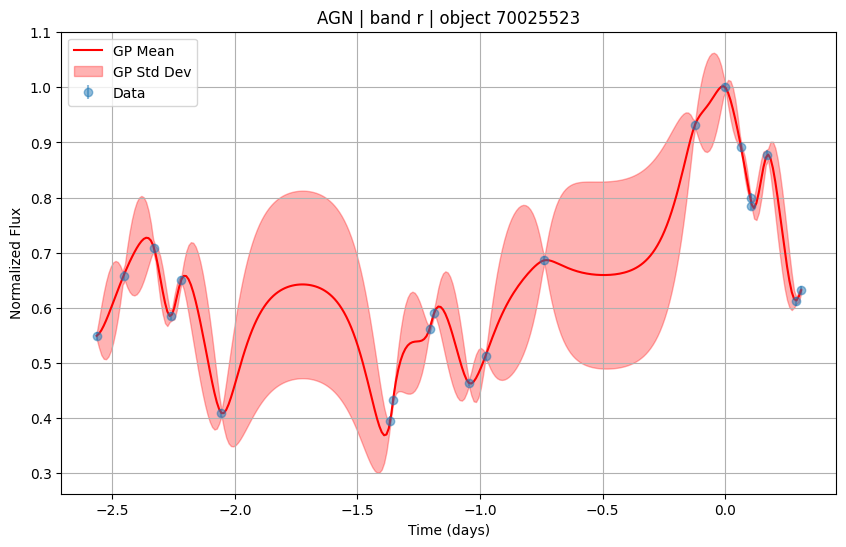

ell = 0.3
kernel after fit: 1**2 * Matern(length_scale=0.3, nu=1.5)


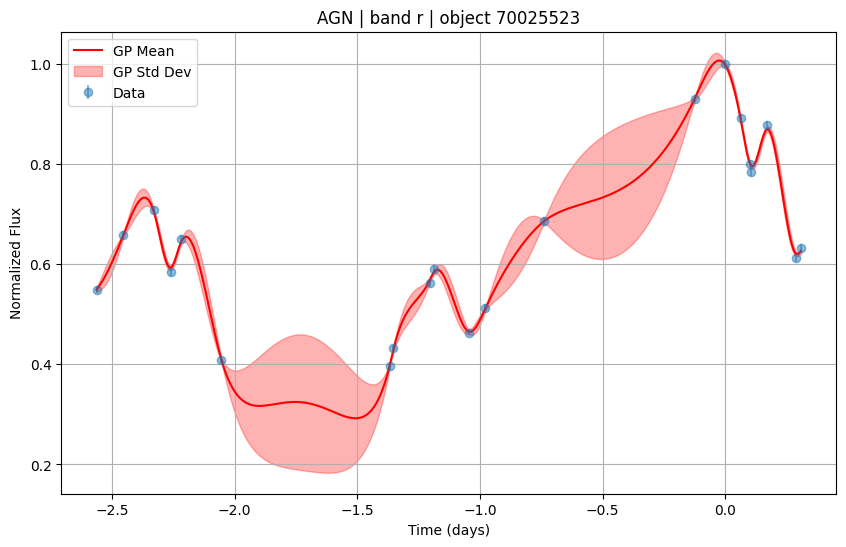

ell = 0.5
kernel after fit: 1**2 * Matern(length_scale=0.5, nu=1.5)


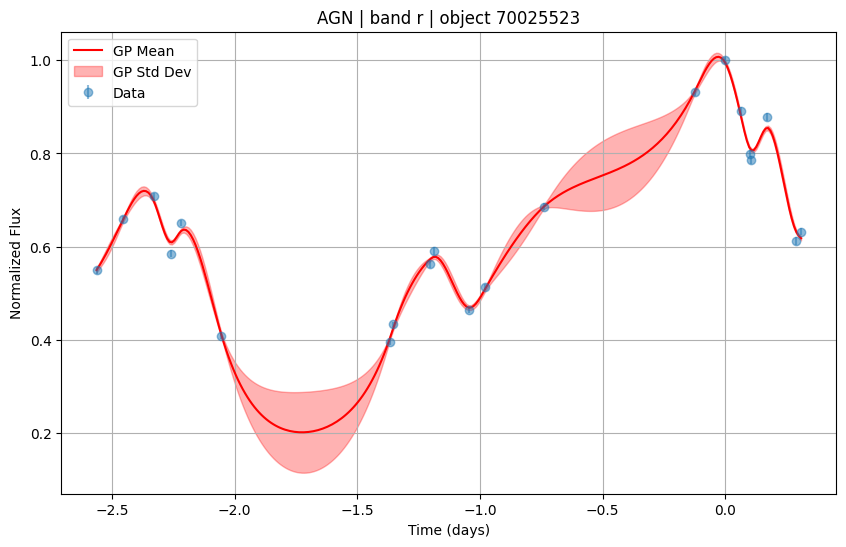

ell = 1.0
kernel after fit: 1**2 * Matern(length_scale=1, nu=1.5)


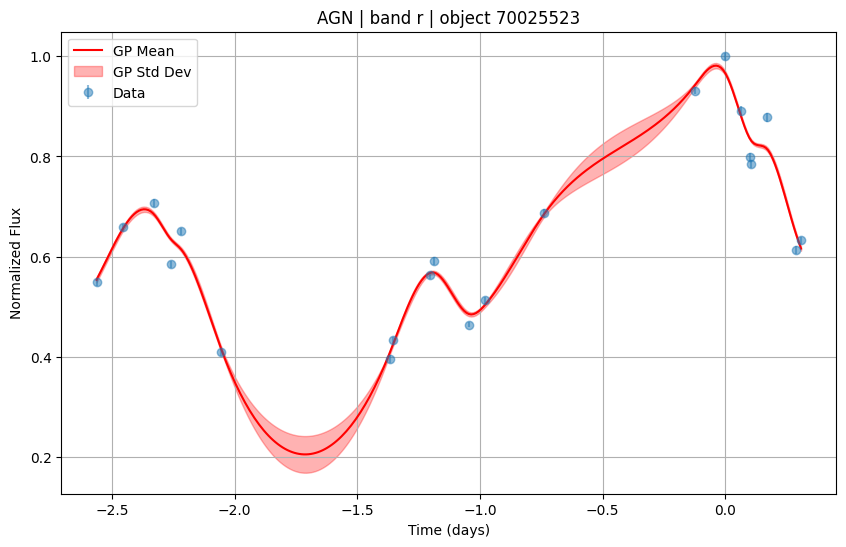

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
# Find the optimal length scale for the Matern kernel across the first 200 objects
data = prepared_objects[101]
for ell in [0.1, 0.3, 0.5, 1.0]:
    kernel = ConstantKernel(1.0) * Matern(length_scale=ell, nu=1.5)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=data["yerr"]**2 + 0.03**2 + 1e-6,
        normalize_y=True,
        optimizer=None,
    )

    gp.fit(data["X"], data["y"])
    print("ell =", ell)
    print("kernel after fit:", gp.kernel_)

    plot_gp_fit(gp, data)

## NLPD Evaluation
-- Negative log predictive density

In [3]:

plasticc_iter = iter(dset_plasticc)

NLPD: -0.37383763767177014
RMSE: 0.20453199752823623
Coverage:
k=1 0.5
k=2 1.0
k=3 1.0


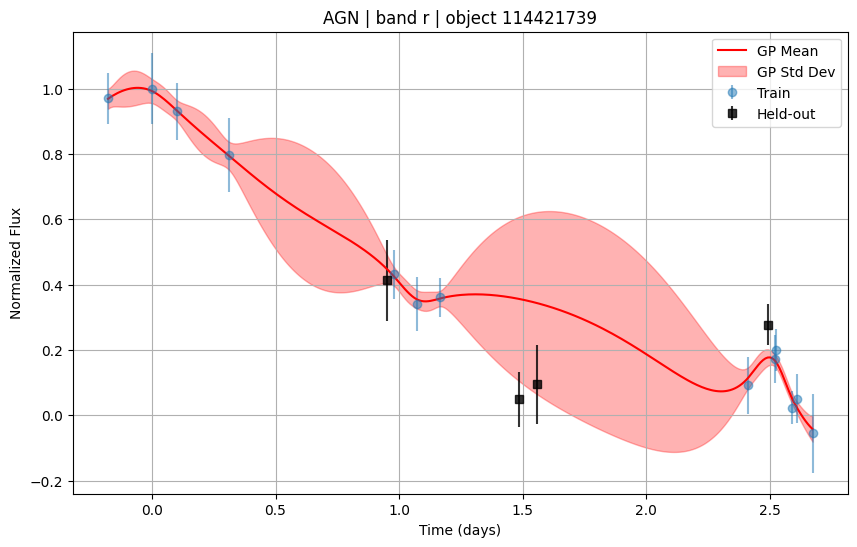

In [4]:
example = next(plasticc_iter)
data = process_one_obj_one_band(example, target_band='r')
train_data, heldout_data = split_train_heldout_observations(
    data,
    heldout_fraction=0.2,
    random_state=0,
    strategy="random",  # or "last"
)

gp = fit_basic_gp(train_data, kernel_type="matern")
nlpd = evaluate_heldout_nlpd(gp, heldout_data)
rmse = evaluate_heldout_rmse(gp, heldout_data)
coverage1 = cover_factor(gp, heldout_data, sigma_multiplier=1.0)
coverage2 = cover_factor(gp, heldout_data, sigma_multiplier=2.0)
coverage3 = cover_factor(gp, heldout_data, sigma_multiplier=3.0)

print("NLPD:", nlpd["mean_nlpd"])
print("RMSE:", rmse["rmse"])
print("Coverage:")
print("k=1", coverage1)   # ~68% for a well-calibrated model
print("k=2", coverage2)   # ~95% for a well-calibrated model
print("k=3", coverage3)   # ~99% for a well-calibrated model
plot_gp_fit(gp, train_data, heldout_data=heldout_data)


## Average Metrics Across Many Objects

Compute observation-weighted and object-weighted averages for NLPD, RMSE, and coverage.


In [2]:
n_objects_target = 300
max_examples_to_scan = 3000
target_band = "r"
global_flux_percentile = 99
min_points = 8

selected_examples, flux_scale, scanned_examples = select_examples_and_global_flux_scale(
    iter(dset_plasticc),
    target_band=target_band,
    n_objects=n_objects_target,
    max_examples_to_scan=max_examples_to_scan,
    percentile=global_flux_percentile,
    min_points=min_points,
)

object_results1 = []
object_results2 = []
object_results3 = []
object_results4 = []

failed_objects = 0

for object_idx, example in enumerate(selected_examples):
    data = process_one_obj_one_band(
        example,
        flux_scale=flux_scale,
        target_band=target_band,
        align_peak=True,
        normalize_flux=True,
        min_points=min_points,
    )
    if data is None:
        continue

    try:
        train_data, heldout_data = split_train_heldout_observations(
            data,
            heldout_fraction=0.2,
            min_train_points=5,
            min_heldout_points=1,
            random_state=object_idx,
            strategy="random",
        )

        # fixed length scale to prevent optimization issues
        gp1 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            length_scale=0.3,
            length_scale_bounds="fixed",
        )

        # fixed both length scale and constant value to prevent optimization issues
        gp2 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            length_scale=0.3,
            length_scale_bounds="fixed",
            constant_value=1.0,
            constant_value_bounds="fixed",
        )  

        # fixed only the constant value to see if it helps with calibration
        gp3 = fit_basic_gp(
            train_data,
            kernel_type="matern",
            constant_value=1.0,
            constant_value_bounds="fixed",
        )

        # don't fix anything and let it optimize to see how it performs and if it fails more often
        gp4 = fit_basic_gp(
            train_data,
            kernel_type="matern",
        )

        metrics1 = evaluate_heldout_metrics(
            gp1,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
        )

        metrics2 = evaluate_heldout_metrics(
            gp2,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
        )

        metrics3 = evaluate_heldout_metrics(
            gp3,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
        )

        metrics4 = evaluate_heldout_metrics(
            gp4,
            heldout_data,
            train_data=train_data,
            coverage_sigmas=(1.0, 2.0, 3.0),
        )

        metrics1["obj_id"] = data["obj_id"]
        metrics1["obj_type"] = data["obj_type"]
        metrics1["gp"] = gp1
        metrics1["train_data"] = train_data
        metrics1["heldout_data"] = heldout_data
        object_results1.append(metrics1)

        metrics2["obj_id"] = data["obj_id"]
        metrics2["obj_type"] = data["obj_type"]
        metrics2["gp"] = gp2
        metrics2["train_data"] = train_data
        metrics2["heldout_data"] = heldout_data
        object_results2.append(metrics2)

        metrics3["obj_id"] = data["obj_id"]
        metrics3["obj_type"] = data["obj_type"]
        metrics3["gp"] = gp3
        metrics3["train_data"] = train_data
        metrics3["heldout_data"] = heldout_data
        object_results3.append(metrics3)

        metrics4["obj_id"] = data["obj_id"]
        metrics4["obj_type"] = data["obj_type"]
        metrics4["gp"] = gp4
        metrics4["train_data"] = train_data
        metrics4["heldout_data"] = heldout_data
        object_results4.append(metrics4)

    except Exception as err:
        failed_objects += 1
        continue

summary1 = summarize_object_metric_results(object_results1)
summary2 = summarize_object_metric_results(object_results2)
summary3 = summarize_object_metric_results(object_results3)
summary4 = summarize_object_metric_results(object_results4)



/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/

In [3]:
print(f"stream examples scanned: {scanned_examples}")
print(f"selected usable objects: {len(selected_examples)}")
print(f"global {global_flux_percentile}th percentile flux scale: {flux_scale:.6g}")
print(f"usable objects evaluated: {summary1['n_objects']}")
print(f"total held-out observations: {summary1['n_heldout_total']}")
print(f"failed fits/splits skipped: {failed_objects}")

print("\nObservation-weighted average")
print("Model 1: fixed length scale")
for metric, value in summary1["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 2: fixed length scale and constant value")
for metric, value in summary2["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 3: fixed constant value")
for metric, value in summary3["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 4: no fixed hyperparameters")
for metric, value in summary4["observation_weighted"].items():
    print(f"{metric}: {value:.4f}")

print("\nObject-weighted average")
print("Model 1: fixed length scale")
for metric, value in summary1["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 2: fixed length scale and constant value")
for metric, value in summary2["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 3: fixed constant value")
for metric, value in summary3["object_weighted"].items():
    print(f"{metric}: {value:.4f}")
print("Model 4: no fixed hyperparameters")
for metric, value in summary4["object_weighted"].items():
    print(f"{metric}: {value:.4f}")

stream examples scanned: 300
selected usable objects: 300
global 99th percentile flux scale: 868.272
usable objects evaluated: 300
total held-out observations: 1538
failed fits/splits skipped: 0

Observation-weighted average
Model 1: fixed length scale
nlpd: -1.5497
rmse: 0.4227
coverage_1sigma: 0.6808
coverage_2sigma: 0.8732
coverage_3sigma: 0.9395
Model 2: fixed length scale and constant value
nlpd: 4.9091
rmse: 0.2401
coverage_1sigma: 0.5507
coverage_2sigma: 0.7744
coverage_3sigma: 0.8797
Model 3: fixed constant value
nlpd: -0.8721
rmse: 0.1867
coverage_1sigma: 0.7373
coverage_2sigma: 0.9051
coverage_3sigma: 0.9545
Model 4: no fixed hyperparameters
nlpd: -2.0235
rmse: 0.1989
coverage_1sigma: 0.7770
coverage_2sigma: 0.9259
coverage_3sigma: 0.9649

Object-weighted average
Model 1: fixed length scale
nlpd: -1.5408
rmse: 0.0778
coverage_1sigma: 0.6817
coverage_2sigma: 0.8743
coverage_3sigma: 0.9404
Model 2: fixed length scale and constant value
nlpd: 4.7020
rmse: 0.0562
coverage_1sigma:

Model 2 is the most rigid one and correspondingly has the worst performace. 
For Model 1,3,4:
The 1st coverage is often too high or near ideal, 
2nd and 3rd coverage is too low. It's likely that the Gaussian predictive distribution is not capturing the tail behavior of the errors.

Hence, we investigate the standardized residuals.

## Standardized Residual Diagnostics

Pool held-out predictions across all selected objects and compute `z = (y_test - y_mean) / y_std`.


In [3]:
model_results = {
    "Model 1: fixed length scale": object_results1,
    "Model 2: fixed length scale and constant value": object_results2,
    "Model 3: fixed constant value": object_results3,
    "Model 4: no fixed hyperparameters": object_results4,
}

for model_name, results in model_results.items():
    stats = standardized_residual_statistics(results)
    print(f"\n{model_name}")
    print("mean z:", stats["mean_z"])
    print("std z:", stats["std_z"])
    print("1σ:", stats["coverage_1sigma"])
    print("2σ:", stats["coverage_2sigma"])
    print("3σ:", stats["coverage_3sigma"])
    print("max |z|:", stats["max_abs_z"])
    print("95% |z|:", stats["p95_abs_z"])
    print("99% |z|:", stats["p99_abs_z"])



Model 1: fixed length scale
mean z: -0.03267455101492573
std z: 1.8752345046685748
1σ: 0.6807542262678804
2σ: 0.8732119635890767
3σ: 0.9395318595578673
max |z|: 22.980964245502047
95% |z|: 3.3623986150423484
99% |z|: 6.878572347659838

Model 2: fixed length scale and constant value
mean z: 0.05483472787329068
std z: 4.214551777033656
1σ: 0.5507152145643693
2σ: 0.7743823146944083
3σ: 0.8797139141742523
max |z|: 59.68548879490047
95% |z|: 5.456816969694363
99% |z|: 16.747484376825625

Model 3: fixed constant value
mean z: 0.054111320396638685
std z: 2.270481795706902
1σ: 0.7373211963589077
2σ: 0.9050715214564369
3σ: 0.9544863459037711
max |z|: 37.45554282914615
95% |z|: 2.838044065150106
99% |z|: 8.422744350459293

Model 4: no fixed hyperparameters
mean z: -0.015100987470715874
std z: 1.5730658298102373
1σ: 0.7769830949284785
2σ: 0.9258777633289987
3σ: 0.9648894668400521
max |z|: 21.040500550212876
95% |z|: 2.4264163644326473
99% |z|: 6.4370681527443665


## Largest Standardized Residual Cases

Print and plot the held-out points with the largest absolute standardized residuals for each model.



Model 1: fixed length scale
object_id: 34866353 band: r time: -1.2832491 X_test: [-1.2832491] y: -3.5218093 mean: 0.627686614790286 std: 0.18056230843863577 z: -22.980964245502047 yerr: 0.032469682 outside_train_range: False near_peak: False n_train: 17
object_id: 30398950 band: r time: 0.0 X_test: [0.] y: 0.4462402 mean: 0.052859392570099285 std: 0.019705417000382284 z: 19.96307888909701 yerr: 0.0047568763 outside_train_range: False near_peak: True n_train: 16
object_id: 48625068 band: r time: 0.0 X_test: [0.] y: 0.093799405 mean: -0.39869814361943556 std: 0.03073285578037556 z: 16.02511500847434 yerr: 0.00915515 outside_train_range: False near_peak: True n_train: 20
object_id: 100122518 band: r time: 1.0697802 X_test: [1.0697802] y: -1.6556299 mean: 0.0028576256546803402 std: 0.10990428872532132 z: -15.090289179482504 yerr: 0.041306566 outside_train_range: False near_peak: False n_train: 20
object_id: 89274370 band: r time: 0.0 X_test: [0.] y: -0.2922072 mean: -0.4504787619192014 st

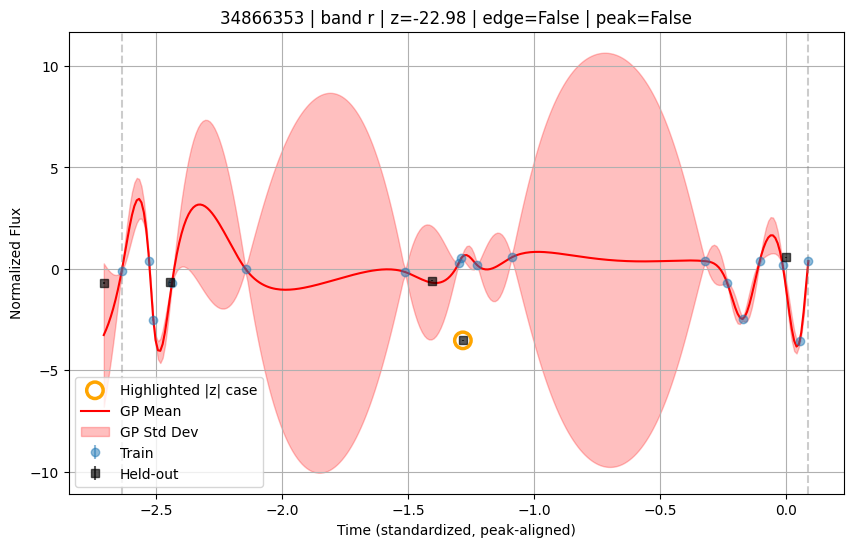

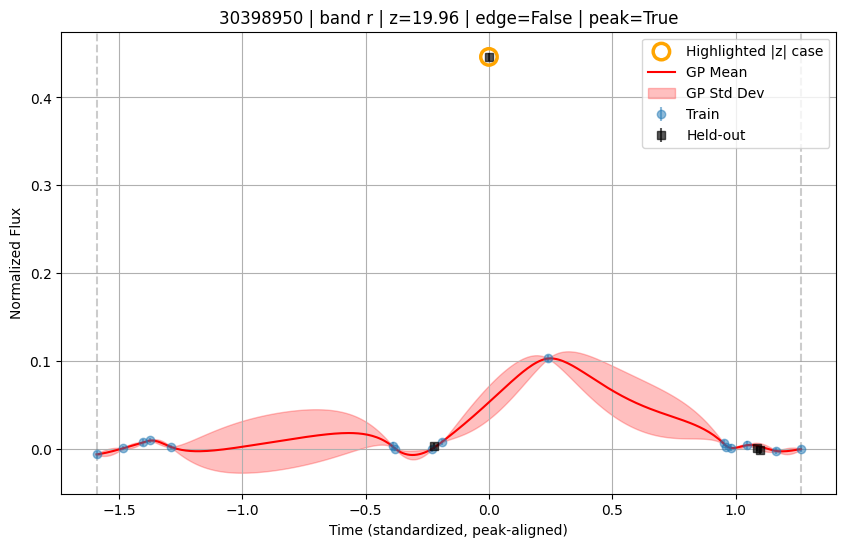

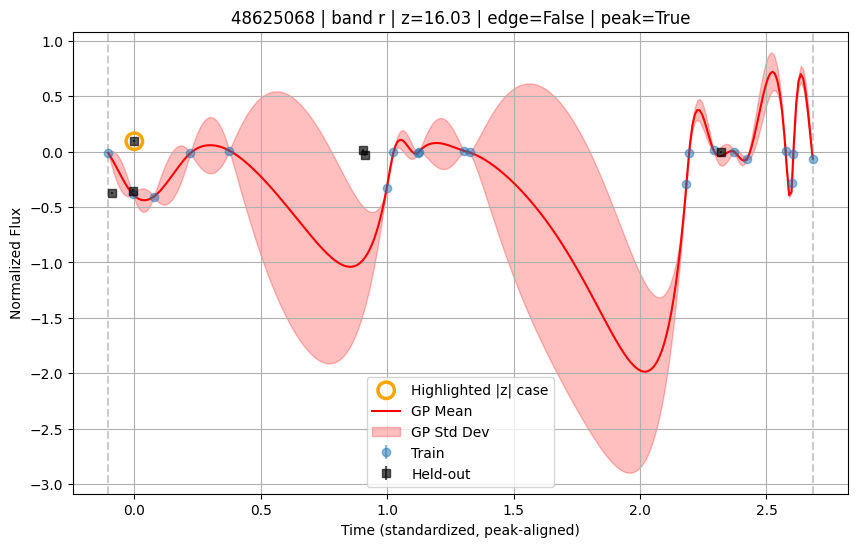

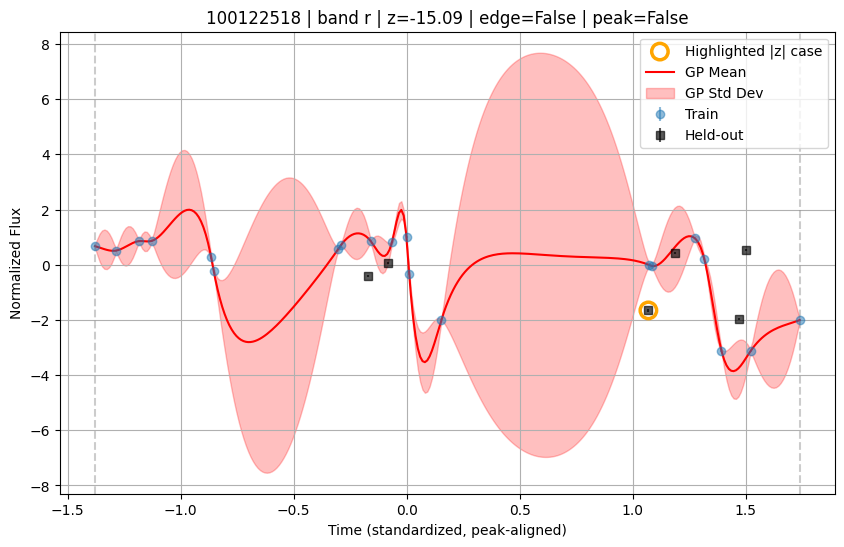

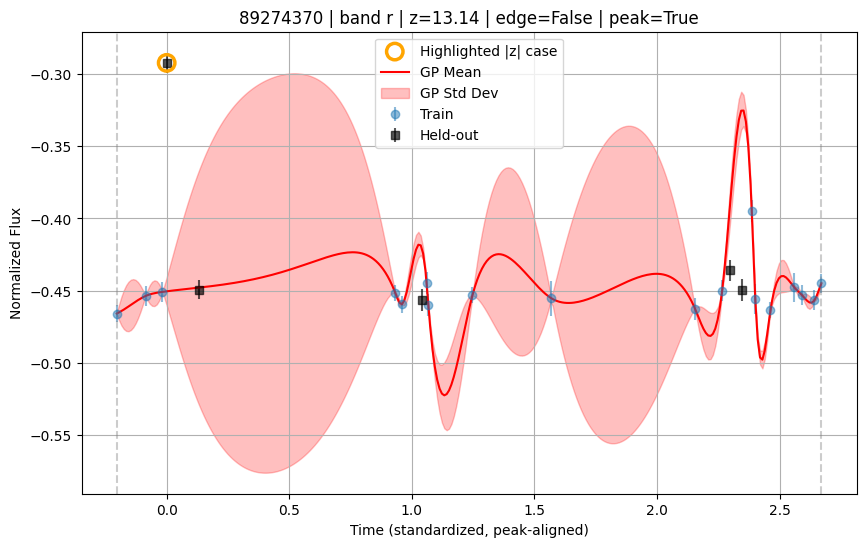


Plots for Model 2: fixed length scale and constant value


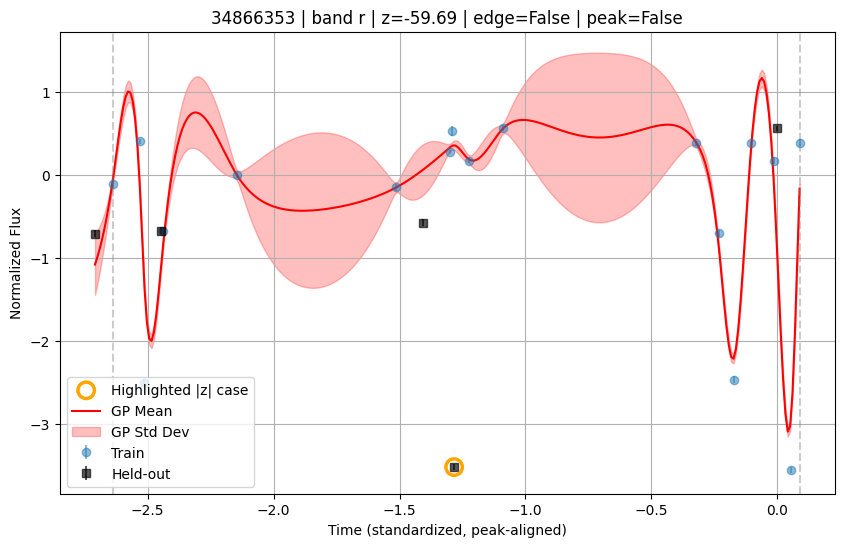

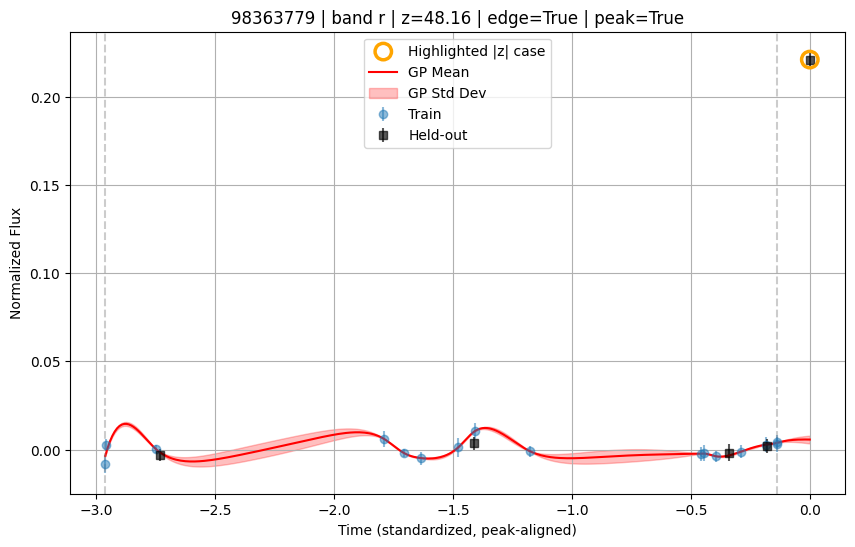

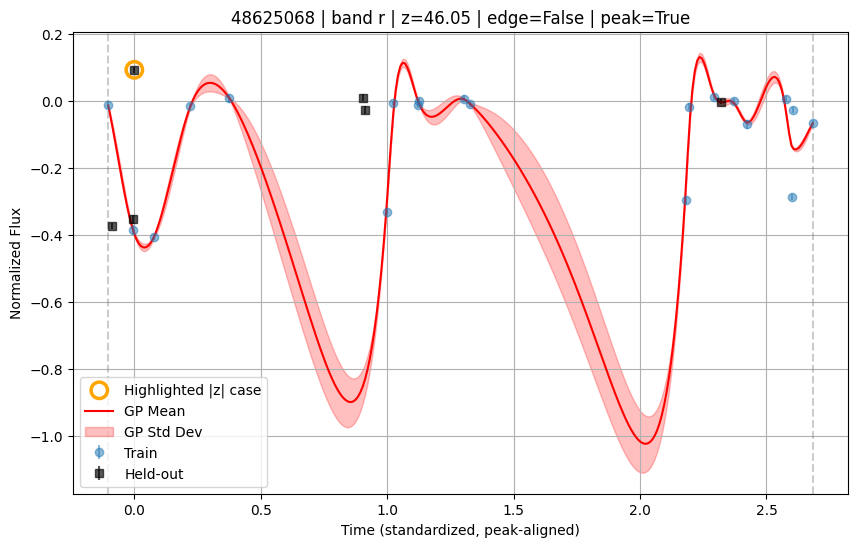

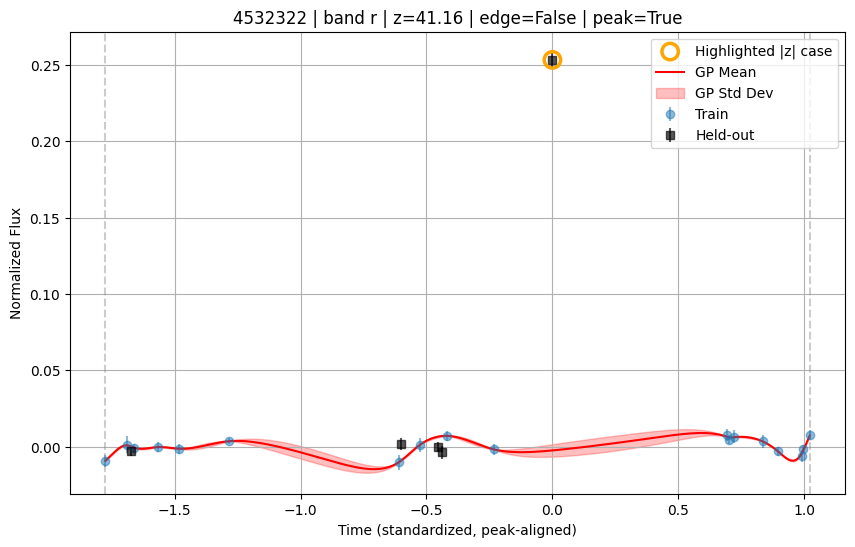

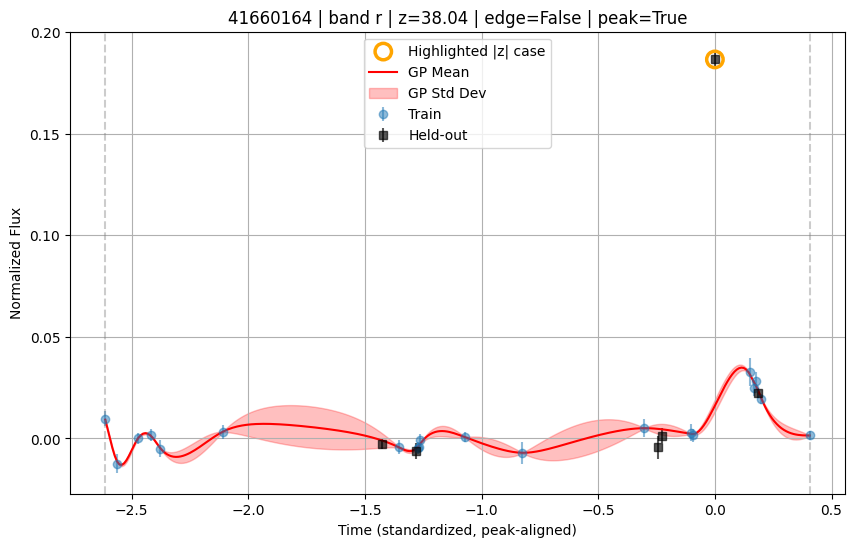


Plots for Model 3: fixed constant value


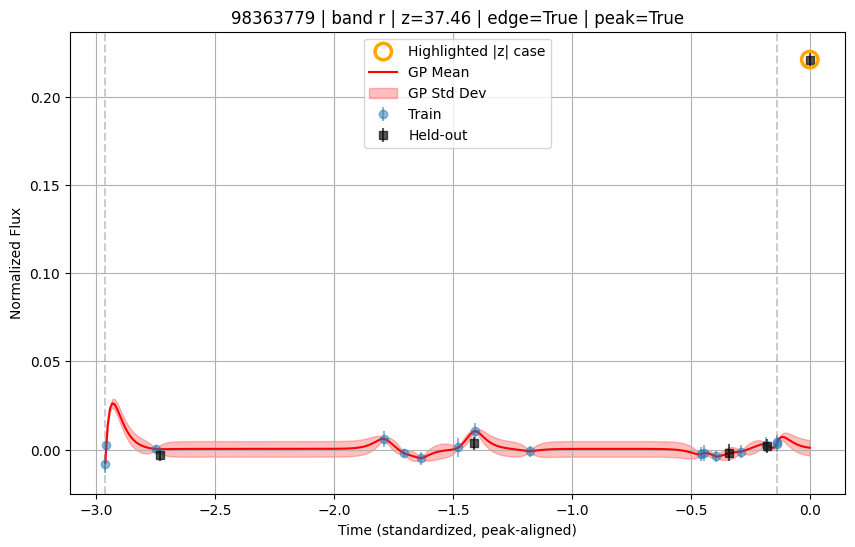

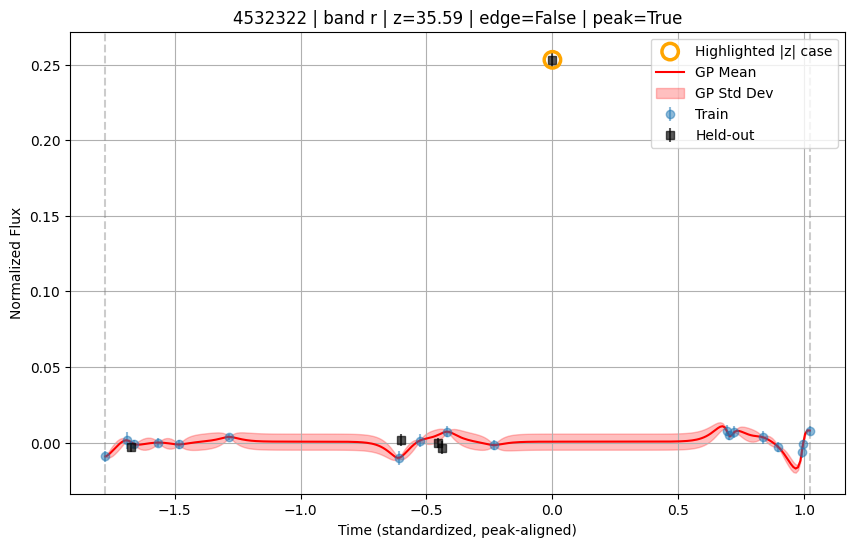

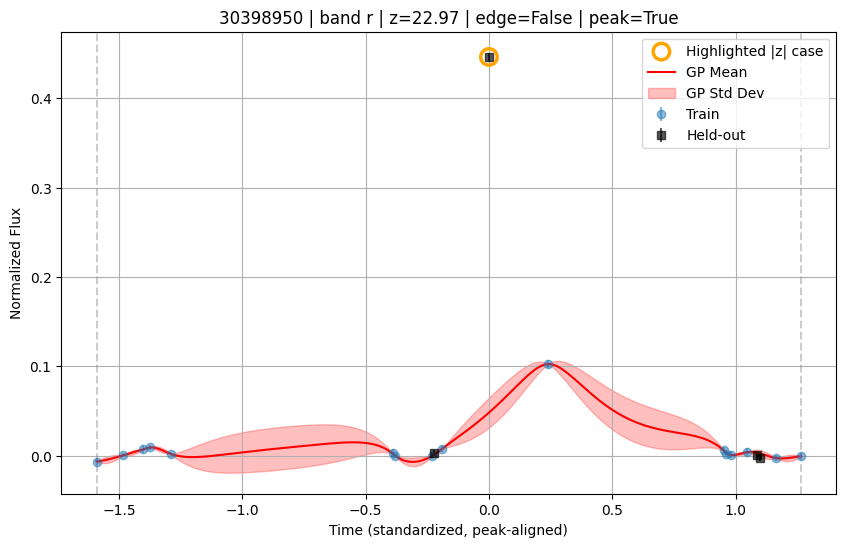

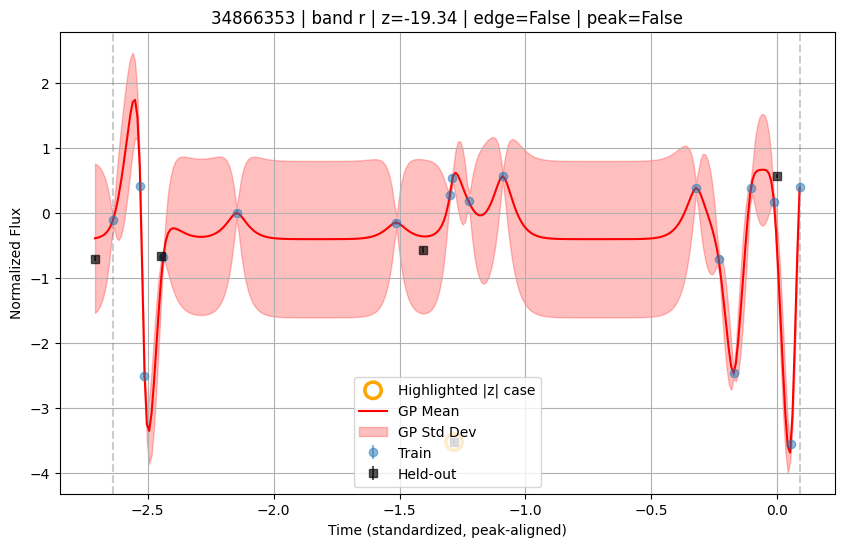

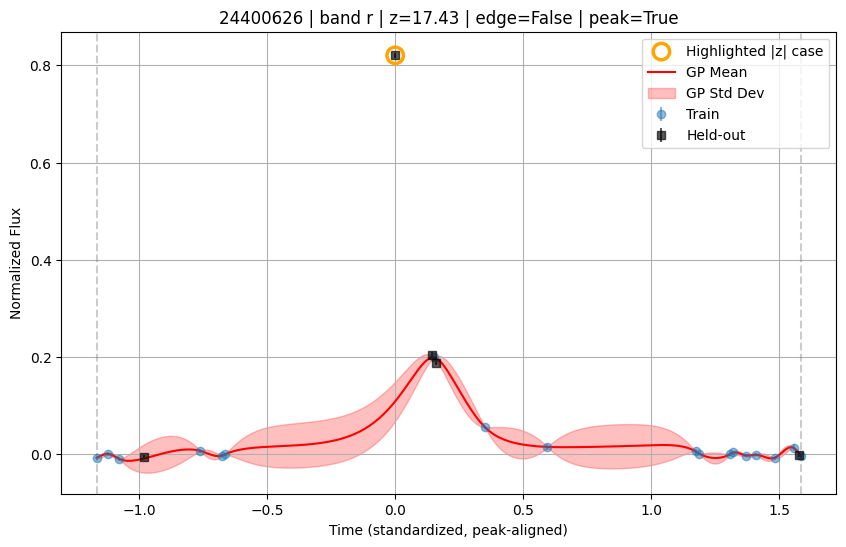


Plots for Model 4: no fixed hyperparameters


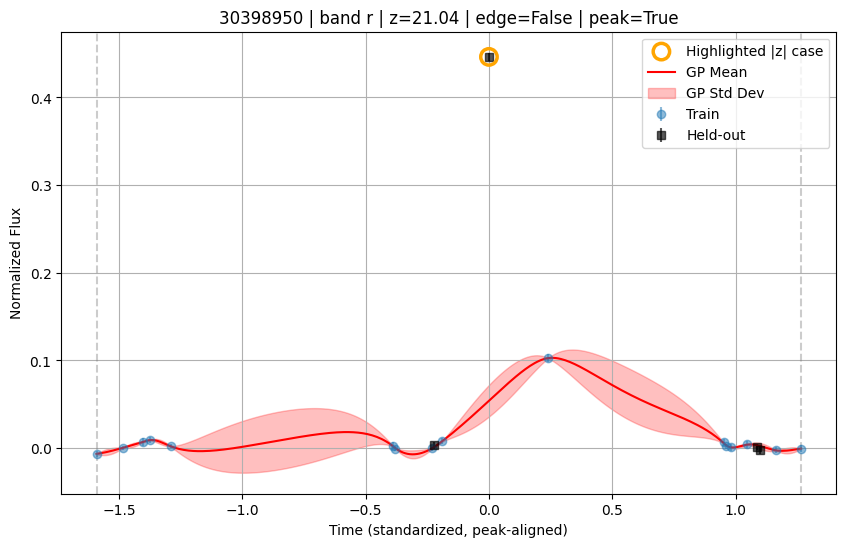

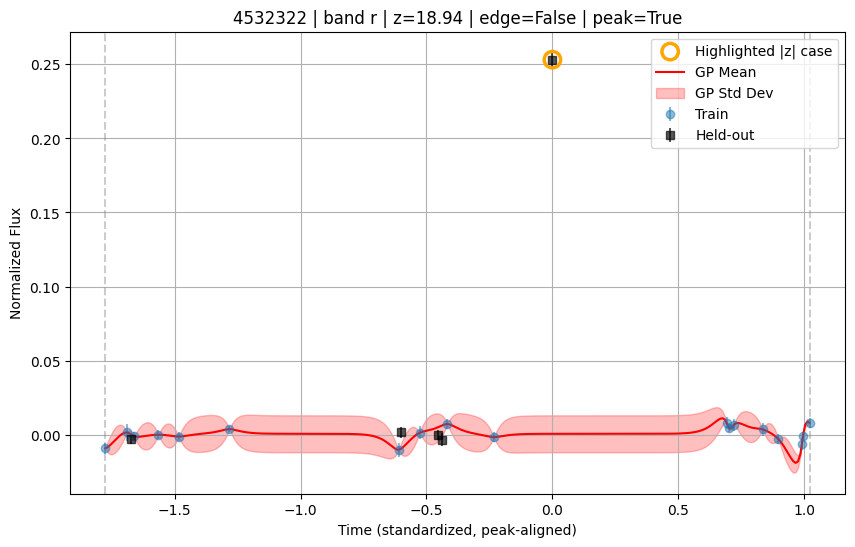

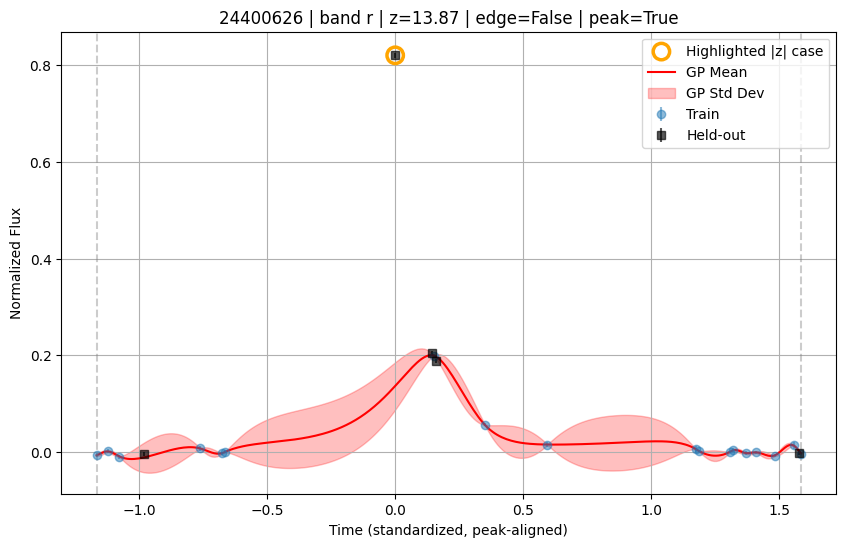

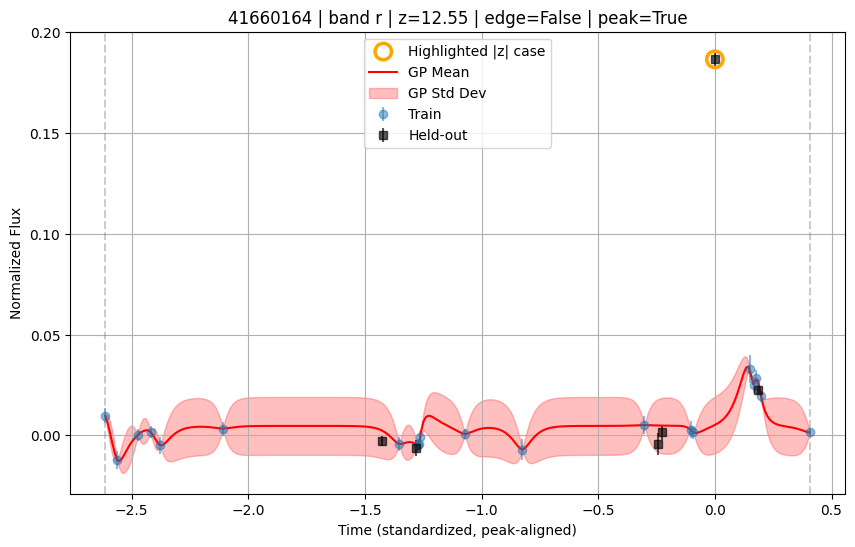

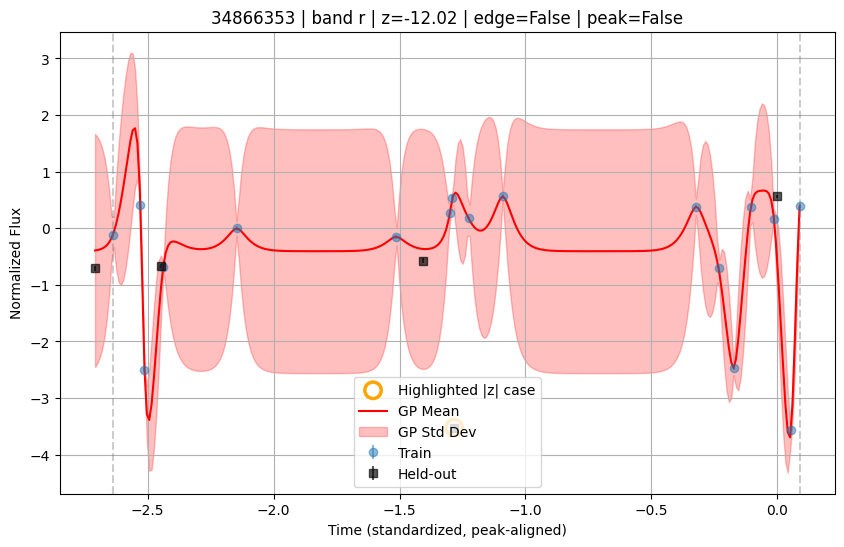

In [4]:
top_cases_by_model = {}

for model_name, results in model_results.items():
    print(f"\n{model_name}")
    cases = print_largest_standardized_residual_cases(results, top_n=10)
    top_cases_by_model[model_name] = cases

# Plot a manageable number first; increase max_plots if you want all 10 per model.
for model_name, results in model_results.items():
    print(f"\nPlots for {model_name}")
    plot_largest_standardized_residual_cases(
        results,
        top_cases_by_model[model_name],
        max_plots=5,
    )


The mean value is around 0, which is fine.

However, all models have too much standardized residual variance, especially Model 2, whereas a calibrated model should have $std(z)~=1$

To conclude:
For many normal observations, predicted intervals are wide enough or slightly too wide.
But for a small number of difficult observations, the model uncertainty is far too small relative to the actual error.

In [5]:
total_objects = 0

for _ in dset_plasticc:
    total_objects += 1

print(total_objects)

7848
